In [224]:
from collections import defaultdict

import pandas as pd
import os
import json

from nlp_content_validity.data.read_data import read_dataset, read_validity

dataset='colquitt_et_al'
# val_metric='htd'
# nlp_metric='htd_nlp'
val_metric='htc'
nlp_metric='mean_focal'
basedir = f'../../data/interim/{dataset}'
models = list(map(lambda x: os.path.splitext(x)[0], filter(lambda x: x.endswith('json'), os.listdir(basedir))))
model = 'sentence_t5'
# model = 'llm_gemini'
# for model in models:
# for val_metric, nlp_metric in [('htd', 'htd_nlp'), ('htc', 'mean_focal')]:
definitions, df_, focal_scales, orbiting_dict = read_dataset(dataset)
relations = {(focal, scale2): label for focal, vals in orbiting_dict.items() for label, scale2 in vals.items()}
for focal in focal_scales:
    relations[(focal, focal)] = 'focal'
filename = f'{model}.json'
model_name = os.path.splitext(filename)[0]
# print(f'processing {basedir}/{filename}')
with open(f'{basedir}/{filename}', 'rb') as f:
    data = json.load(f)
data_dict = defaultdict(dict)
for i in data:
    for k, v in i.items():
        for kk, vv in v.items():
            data_dict[k][relations[(k, kk)]] = vv

similarities=list()
for scale, vals in data_dict.items():
    df=pd.DataFrame(vals)
    df['scale']=scale
    df['item'] = df_[df_.scale==scale].item.values
    similarities.append(df)
df = pd.concat(similarities)
if val_metric == 'htd':
    df[f'item_{nlp_metric}'] = (2*df.focal)-df.orbiting_scale_1-df.orbiting_scale_2
elif val_metric == 'htc':
    df[f'item_{nlp_metric}'] = df.focal
else:
    raise NotImplementedError(f'metric {val_metric} is not implemented')
validities = read_validity(dataset)
df = pd.merge(df, validities, left_on='scale', right_on='focal_scale', how='left')

nlp_metrics = pd.read_csv(f'../../data/processed/{dataset}/{model}.csv', index_col=0).rename(columns={'htd':"htd_nlp"})
merged = pd.merge(validities, nlp_metrics, left_index=True, right_index=True)

merged[f'{val_metric}_rank_diff'] = (merged[f'{val_metric}'].rank()-merged[f'{nlp_metric}'].rank())

df['item_rank_diff'] = df[f'{val_metric}'].rank() - df[f'item_{nlp_metric}'].rank()


In [225]:
import spacy
nlp = spacy.load('en_core_web_trf')

In [226]:
import textacy
from textacy.text_stats import TextStats

In [227]:
import numpy as np


In [228]:
def featurize(txt):
    doc = nlp(txt)
    # - N. sentences, words, chars
    n_sents =textacy.text_stats.n_sents(doc)
    n_words =textacy.text_stats.n_words(doc)
    n_chars =textacy.text_stats.n_chars(doc)
    # - Readability index (ARI, smog, coleman liau, flesch kincaid, gunning fog)
    smog_index = textacy.text_stats.readability.smog_index(doc)
    # - Freq. of parts-of-speech
    pos = {k:v/len(doc) for k, v in textacy.text_stats.counts.pos(doc).items()}
    # - Frac. of function words, e.g. for, to, the.
    stopwords = sum(tok.is_stop for tok in doc)/len(doc)
    # - Median chars/syllables per word
    n_chars_per_word = np.mean(textacy.text_stats.basics.n_chars_per_word(doc))
    n_syllables_per_word = np.mean(textacy.text_stats.basics.n_syllables_per_word(doc))
    # - Frac. of punctuation (e.g. ‘,’ ‘.’)
    punct=sum(tok.is_punct for tok in doc)/len(doc)
    # - Type-token ratio
    log_ttr =textacy.text_stats.diversity.log_ttr(doc)
    return dict(smog_index=smog_index,
        stopwords=stopwords,
        n_chars_per_word=n_chars_per_word,
        n_syllables_per_word=n_syllables_per_word,
        punct=punct,
        n_sents=n_sents,
        n_words=n_words,
        n_chars=n_chars,
        log_ttr=log_ttr) |pos

In [250]:
[tok for txt in df_.item.values for tok in nlp(txt) if tok.pos_=='SYM']

[/,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /,
 /]

In [229]:
defs =pd.Series(definitions)
defs_featurized = pd.DataFrame(defs.apply(featurize).tolist(), index=defs.index).fillna(0.).rename(columns=lambda x: 'definition_'+x)

In [230]:
scale_items=df_.groupby('scale').item.agg(lambda x:'\n '.join(x))

In [231]:
featurized =pd.DataFrame(scale_items.apply(featurize).tolist(), index=scale_items.index).fillna(0.)

In [232]:
n_items =df_.groupby('scale').size()

In [233]:
featurized['n']=n_items

In [234]:
featurized = featurized.rename(columns=lambda x: 'item_'+x)

In [235]:
featurized =pd.merge(defs_featurized, featurized, left_index=True, right_index=True)

In [236]:
featurized =pd.merge(featurized, merged[[val_metric, nlp_metric, f'{val_metric}_rank_diff']], left_index=True, right_index=True)

In [237]:
feature_names=[i for i in featurized.columns if i not in [f'{val_metric}_rank_diff', nlp_metric]]
X = featurized[feature_names].values
y=featurized[nlp_metric].values

In [238]:
from pytorch_tabnet import TabNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TabNet prefers scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [239]:
regressor = TabNetRegressor()

regressor.fit(
    X_train_scaled, y_train.reshape(-1, 1),
    eval_set=[(X_test_scaled, y_test.reshape(-1, 1))],
    eval_metric=["rmse"],
    max_epochs=100,
    patience=20,
    batch_size=32,
    virtual_batch_size=16,
compute_importance=True
)


epoch 0  | loss: 6.33683 | val_0_rmse: 1.19761 |  0:00:00s


C:\Users\matti\PycharmProjects\nlp_content_validity\.venv1\lib\site-packages\pytorch_tabnet\tab_models\tab_reg.py:22: UserWarning: Device used : cpu
  super(TabNetRegressor, self).__post_init__()


epoch 1  | loss: 4.10907 | val_0_rmse: 1.06896 |  0:00:00s
epoch 2  | loss: 2.41409 | val_0_rmse: 0.94916 |  0:00:00s
epoch 3  | loss: 1.53259 | val_0_rmse: 0.84766 |  0:00:00s
epoch 4  | loss: 0.88773 | val_0_rmse: 0.76697 |  0:00:00s
epoch 5  | loss: 0.59732 | val_0_rmse: 0.69064 |  0:00:00s
epoch 6  | loss: 0.32512 | val_0_rmse: 0.59719 |  0:00:00s
epoch 7  | loss: 0.26768 | val_0_rmse: 0.52013 |  0:00:01s
epoch 8  | loss: 0.28781 | val_0_rmse: 0.46211 |  0:00:01s
epoch 9  | loss: 0.22158 | val_0_rmse: 0.42661 |  0:00:01s
epoch 10 | loss: 0.21802 | val_0_rmse: 0.3856  |  0:00:01s
epoch 11 | loss: 0.19793 | val_0_rmse: 0.41775 |  0:00:01s
epoch 12 | loss: 0.13486 | val_0_rmse: 0.4445  |  0:00:01s
epoch 13 | loss: 0.1031  | val_0_rmse: 0.41394 |  0:00:01s
epoch 14 | loss: 0.08552 | val_0_rmse: 0.38175 |  0:00:01s
epoch 15 | loss: 0.07778 | val_0_rmse: 0.35777 |  0:00:01s
epoch 16 | loss: 0.05591 | val_0_rmse: 0.33464 |  0:00:01s
epoch 17 | loss: 0.06657 | val_0_rmse: 0.3064  |  0:00:0

C:\Users\matti\PycharmProjects\nlp_content_validity\.venv1\lib\site-packages\pytorch_tabnet\callbacks\container.py:113: UserWarning: Best weights from best epoch are automatically used!
  callback.on_train_end(logs)


In [240]:
importances = regressor.feature_importances_

for fname, importance in zip(feature_names, importances):
    print(f"{fname}: {importance:.4f}")


definition_smog_index: 0.0000
definition_stopwords: 0.0105
definition_n_chars_per_word: 0.0000
definition_n_syllables_per_word: 0.0014
definition_punct: 0.0045
definition_n_sents: 0.0022
definition_n_words: 0.0006
definition_n_chars: 0.0895
definition_log_ttr: 0.0111
definition_NOUN: 0.1159
definition_PRON: 0.0363
definition_VERB: 0.0191
definition_CCONJ: 0.0000
definition_ADP: 0.0324
definition_PUNCT: 0.0181
definition_DET: 0.0002
definition_PART: 0.0119
definition_ADV: 0.0170
definition_ADJ: 0.0239
definition_AUX: 0.0000
definition_NUM: 0.0000
definition_X: 0.0038
definition_SCONJ: 0.0103
definition_PROPN: 0.0012
definition_SYM: 0.0073
item_smog_index: 0.0000
item_stopwords: 0.0730
item_n_chars_per_word: 0.0100
item_n_syllables_per_word: 0.0193
item_punct: 0.0074
item_n_sents: 0.0105
item_n_words: 0.0028
item_n_chars: 0.1017
item_log_ttr: 0.0000
item_PRON: 0.0501
item_VERB: 0.0065
item_NOUN: 0.0031
item_SCONJ: 0.0244
item_PART: 0.0243
item_ADP: 0.0002
item_ADJ: 0.0007
item_SPACE: 0.0

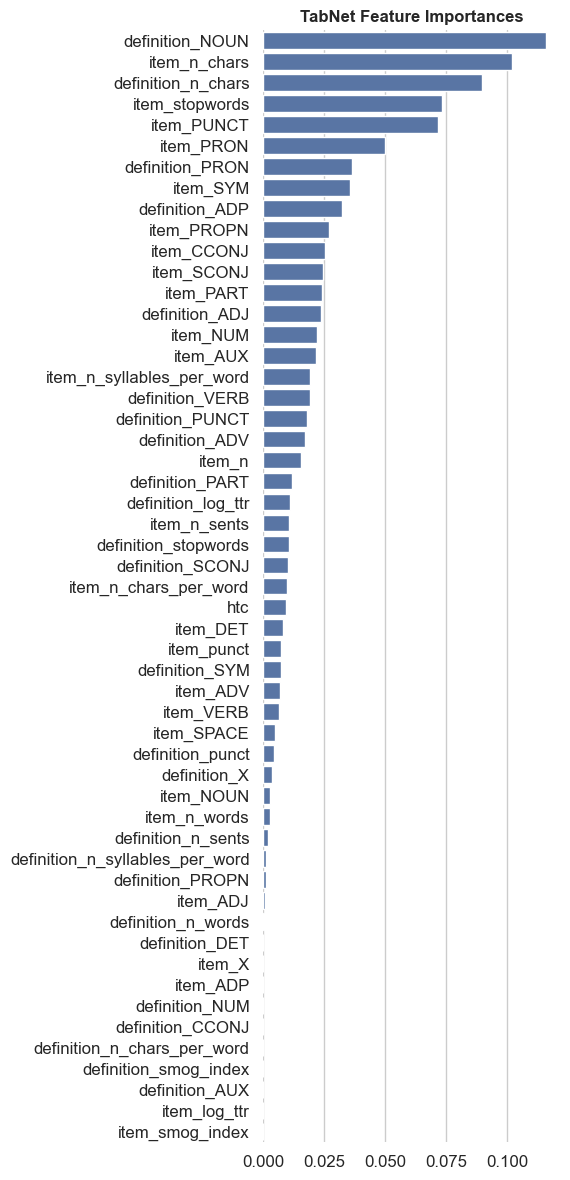

In [241]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose these are your features and importances
importances = regressor.feature_importances_  # your importances array

# Prepare DataFrame
df_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(6, 12))
ax = sns.barplot(data=df_imp, x="Importance", y="Feature", color="#4c72b0")

ax.set_title("TabNet Feature Importances", fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()



Sample 0 (y = 0.838779017329216):

Sample 1 (y = 0.8933675765991211):

Sample 2 (y = 0.8479460179805756):

Sample 3 (y = 0.8937056362628937):

Sample 4 (y = 0.8235170602798462):

Sample 5 (y = 0.8767032623291016):

Sample 6 (y = 0.886016771197319):

Sample 7 (y = 0.7187088827292124):

Sample 8 (y = 0.7302600592374802):

Sample 9 (y = 0.8715199828147888):

Sample 10 (y = 0.8631487190723419):

Sample 11 (y = 0.921303316950798):

Sample 12 (y = 0.881282651424408):

Sample 13 (y = 0.8369439601898193):

Sample 14 (y = 0.8211696296930313):

Sample 15 (y = 0.8832275668780009):

Sample 16 (y = 0.8506720463434855):

Sample 17 (y = 0.7468528151512146):

Sample 18 (y = 0.8361486262745328):

Sample 19 (y = 0.7552395388484001):

Sample 20 (y = 0.819312204917272):

Sample 21 (y = 0.8747896154721578):

Sample 22 (y = 0.8699642300605774):


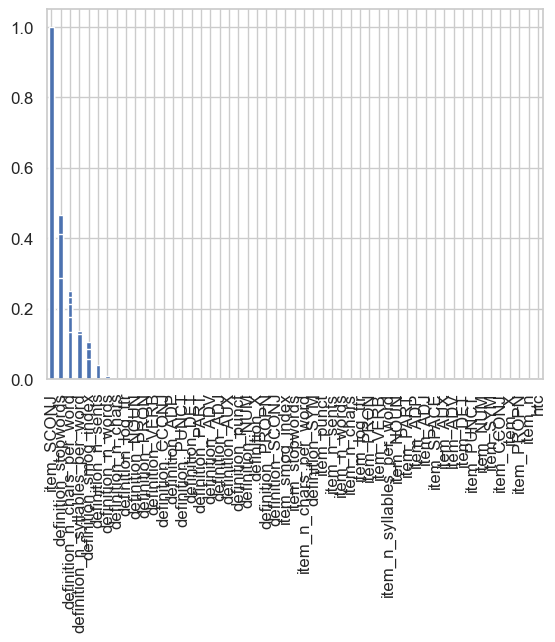

In [242]:
explain_matrix, masks = regressor.explain(X_test_scaled)

for i in range(len(X_test_scaled)):
    print(f"\nSample {i} (y = {y_test[i]}):")
    pd.Series(masks[0][i], index=feature_names).sort_values(ascending=False).plot(kind='bar')

In [243]:
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

feature_names=[i for i in featurized.columns if i not in [f'{val_metric}_rank_diff', val_metric, nlp_metric]]
X = featurized[feature_names].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)  # add intercept
model1 = sm.OLS(featurized[nlp_metric], X_scaled).fit()
model2 = sm.OLS(featurized[val_metric], X_scaled).fit()
# model1.model.exog_names = ['Intercept',]+feature_names
# model2.model.exog_names = ['Intercept',]+feature_names

In [244]:
stargazer = Stargazer([model1, model2])
stargazer.title(f"OLS Regression Results: {nlp_metric} vs {val_metric}")
stargazer.custom_columns([nlp_metric, val_metric], [1, 1])

stargazer.rename_covariates(dict(zip(model2.model.exog_names, ['Intercept',]+feature_names)))
# print(stargazer.render_html())

from IPython.core.display import display, HTML
display(HTML(stargazer.render_html()))

C:\Users\matti\AppData\Local\Temp\ipykernel_43784\3107422823.py:8: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


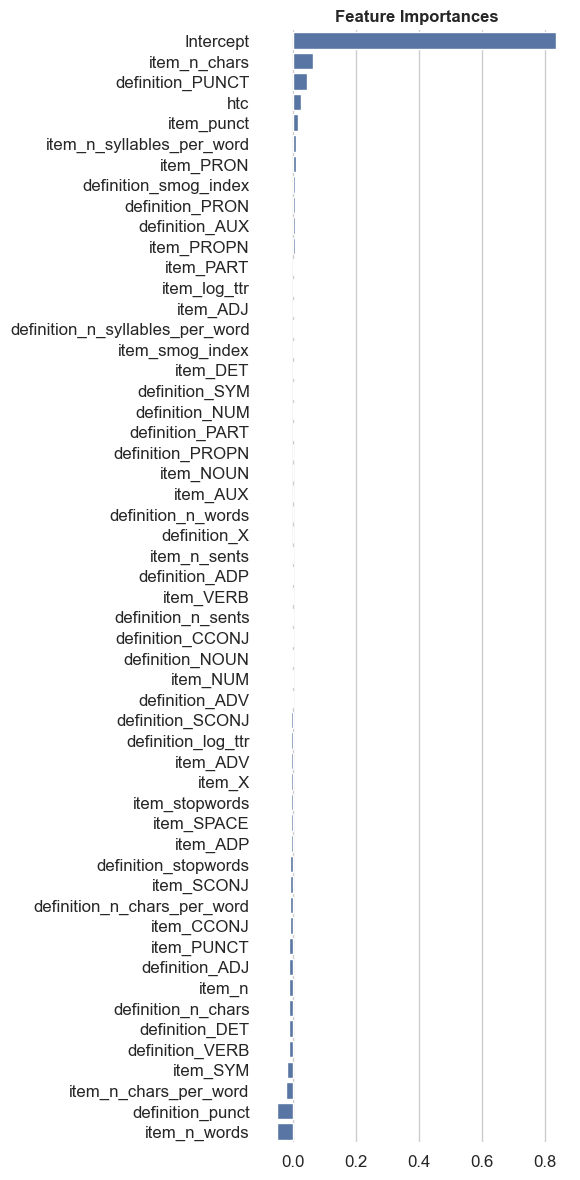

In [245]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_names=[i for i in featurized.columns if i not in [f'{val_metric}_rank_diff', nlp_metric]]
X = featurized[feature_names].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)  # add intercept
model1 = sm.OLS(featurized[nlp_metric], X_scaled).fit()
model1._results.model.data.xnames = ['Intercept', ]+feature_names
coefs = model1.params.sort_values(ascending=False)
coefs.name = "Importance"
coefs.index.name = "Feature"

df_plot = coefs.reset_index()

sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(6, 12))
ax = sns.barplot(data=df_plot, x="Importance", y="Feature", color="#4c72b0")

ax.set_title("Feature Importances", fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


In [246]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
fn = [i for i in feature_names if i not in ['item_n_words', 'item_n_chars', 'definition_n_words', 'definition_n_chars', 'item_NOUN', 'definition_NOUN', 'item_log_ttr', 'definition_log_ttr', 'item_n_chars_per_word', 'definition_n_chars_per_word', 'item_n_syllables_per_word', 'item_stopwords', 'definition_n_sents', 'definition_n_syllables_per_word', 'definition_stopwords', 'definition_PUNCT']]
vif_data = pd.DataFrame()
vif_data["Feature"] = fn
vif_data["VIF"] = [variance_inflation_factor(featurized[fn].values, i) for i in range(featurized[fn].shape[1])]
print(vif_data)

                  Feature         VIF
0   definition_smog_index   38.638202
1        definition_punct    5.566695
2         definition_PRON    6.491695
3         definition_VERB   11.693946
4        definition_CCONJ    5.485192
5          definition_ADP   13.269851
6          definition_DET   10.133672
7         definition_PART    4.789389
8          definition_ADV    1.819732
9          definition_ADJ    5.866289
10         definition_AUX    2.210716
11         definition_NUM    1.560813
12           definition_X    2.181408
13       definition_SCONJ    3.837564
14       definition_PROPN    1.224266
15         definition_SYM    1.413963
16        item_smog_index   23.327916
17             item_punct   17.573190
18           item_n_sents    6.887209
19              item_PRON   24.259602
20              item_VERB   32.363986
21             item_SCONJ    3.664186
22              item_PART    5.827546
23               item_ADP   14.642909
24               item_ADJ    6.940637
25          